<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/AviDetectClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [1]:
!pip install split-folders

In [2]:
import os
import shutil
import random
import splitfolders
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path de Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Usaremos el dataset [Drone vs Bird:Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) disponible públicamente [Kaggle](https://www.kaggle.com) bajo la licencia **Apache 2.0**.

Podemos importar el dataset vía kagglehub.

In [4]:
# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

100%|██████████| 1.59G/1.59G [00:22<00:00, 77.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1


El dataset tiene dos carpetas con 4106 imágenes en total:
* bird: 1607 imágenes
* drone: 2499 imágenes

Sin embargo, está desbalanceado al contar con más imágenes de drones que de aves. Adicionalmente, es necesario hacer el split inicial para obtener train y test. Posteriormente, dividir train en train y validation. Las divisiones comunes para esta división son 70/15/15 u 80/10/10.
Haremos una división de 70% train, 15% validation y 15% test.

In [5]:
def removeDirectories(parentDirectory, directoriesToRemove):
  """
  Remove the directories of a parent directory

  Parameters
  ----------
  parentDirectory : str
    Path to the parent directory you want to clean
  directoriesToRemove : list
    List of the directories to clean

  Returns
  -------
  None
  """
  for directory in directoriesToRemove:
      directoryPath = os.path.join(parentDirectory, directory)

      if os.path.exists(directoryPath):
          shutil.rmtree(directoryPath)
          print(f"Deleted: {directoryPath}")

Tomaremos el dataset de kaggle y el dataset resultado (spliteado) estará en el directorio BirdVSDrone

In [6]:
datasetDirectory = os.path.join(path, "dataset")
outputDirectory = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone"

In [7]:
!ls {datasetDirectory}

bird  drone


In [8]:
directoriesToRemove = ["train", "test", "val"]
removeDirectories(outputDirectory, directoriesToRemove)

Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/val


La librería splitfolders nos permite hacer el split de manera sencilla

In [9]:
splitfolders.ratio(datasetDirectory, output=outputDirectory, seed=42, ratio=(0.7, 0.15, 0.15))

Copying files: 4106 files [01:05, 62.39 files/s]


In [10]:
!ls {outputDirectory}

test  train  val


Dato curioso: La semilla 42 se usa en ocasiones como tradición de programadores y científicos de datos. Aparece de la novela de ciencia ficción de Douglas Adams: *La guía del autoestopista galáctico (1979)*. Aquí, la supercomputadora llamada *Deep though* revela que la respuesta a la gran pregunta de "la vida, el universo y todo lo demás" es 42. Realmente no tiene alguna ventaja computacional.

Verificamos que existan las imagenes

In [11]:
def countImages(directory, directories):
  """
  Count the number of images in a directory

  Parameters
  ----------
  directory : str
    Path to the directory where the images are
  directories : list
    Directories train, test and val that have bird and drone each

  Returns
  -------
  None
  """
  for directory in directories:
    print(f"Images in {directory}:")
    for subdirectory in ["bird", "drone"]:
      totalImages = len(os.listdir(os.path.join(outputDirectory, directory, subdirectory)))
      print(f"{subdirectory}: {totalImages}")

In [12]:
directoriesWithImages = ["train", "test", "val"]
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1124
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


Visualizamos las imagenes que hay

In [13]:
trainDirectory = os.path.join(outputDirectory, "train")
testDirectory = os.path.join(outputDirectory, "test")
valDirectory = os.path.join(outputDirectory, "val")

In [14]:
def getImages(directory, numImages, seed=42):
  """
  Get the images from a directory and show them

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  numImages : int
    Images to show

  Returns
  -------
  None
  """

  random.seed(seed)

  plt.figure(figsize=(10,10))
  images = [i for i in os.listdir(directory) if os.path.isfile(os.path.join(directory, i))]
  random.shuffle(images)
  images = images[:numImages]

  for i, image in enumerate(images):
    img = plt.imread(os.path.join(directory, image))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)

  plt.show()

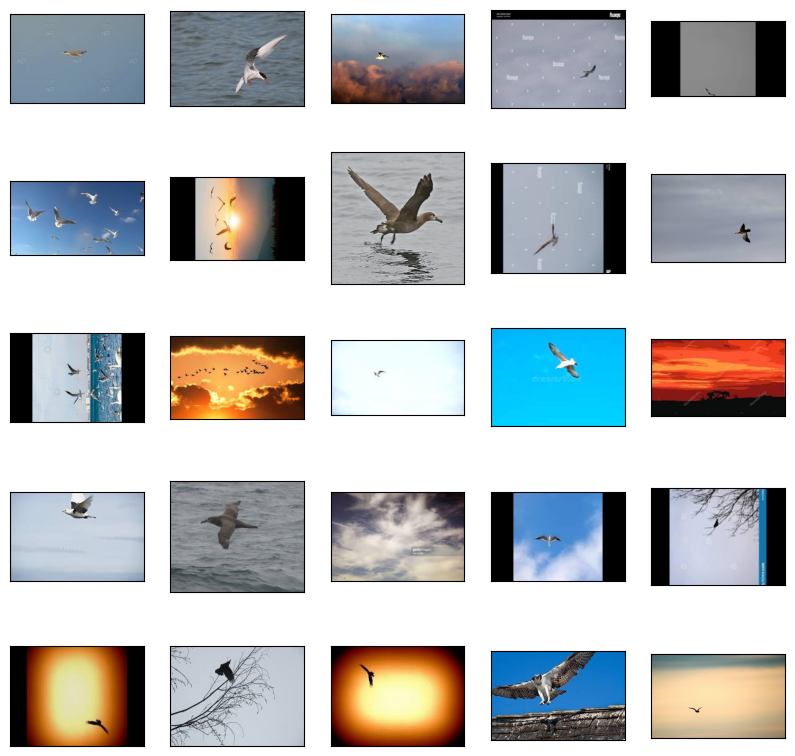

In [15]:
getImages(os.path.join(trainDirectory, "bird"), 25)

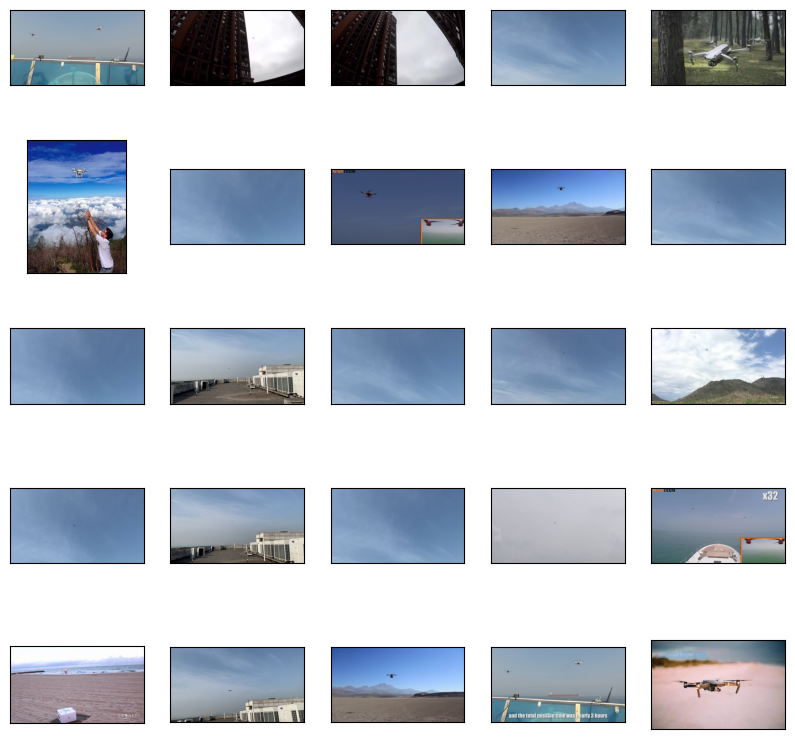

In [16]:
getImages(os.path.join(trainDirectory, "drone"), 25)

# Data augmentation
Usamos ImageDataGenerator para generar imagenes nuevas en el ram mientras entrenamos para no desperdiciar espacio.

In [17]:
trainDatagen = ImageDataGenerator(
    rescale = 1./255, # Mandatory
    rotation_range = 10,
    width_shift_range = 0.2,
    # height_shift_range = 0.2,
    #	shear_range = 0.3,
    zoom_range = 0.3,
    horizontal_flip = True)

Para ello tenemos que asignar una fuente base de imágenes a modificar, en este caso tomamos las de el directorio de train, en este caso sólo se toma una imagen y se muestra como se generarían 5 imágenes diferentes.

Found 2871 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

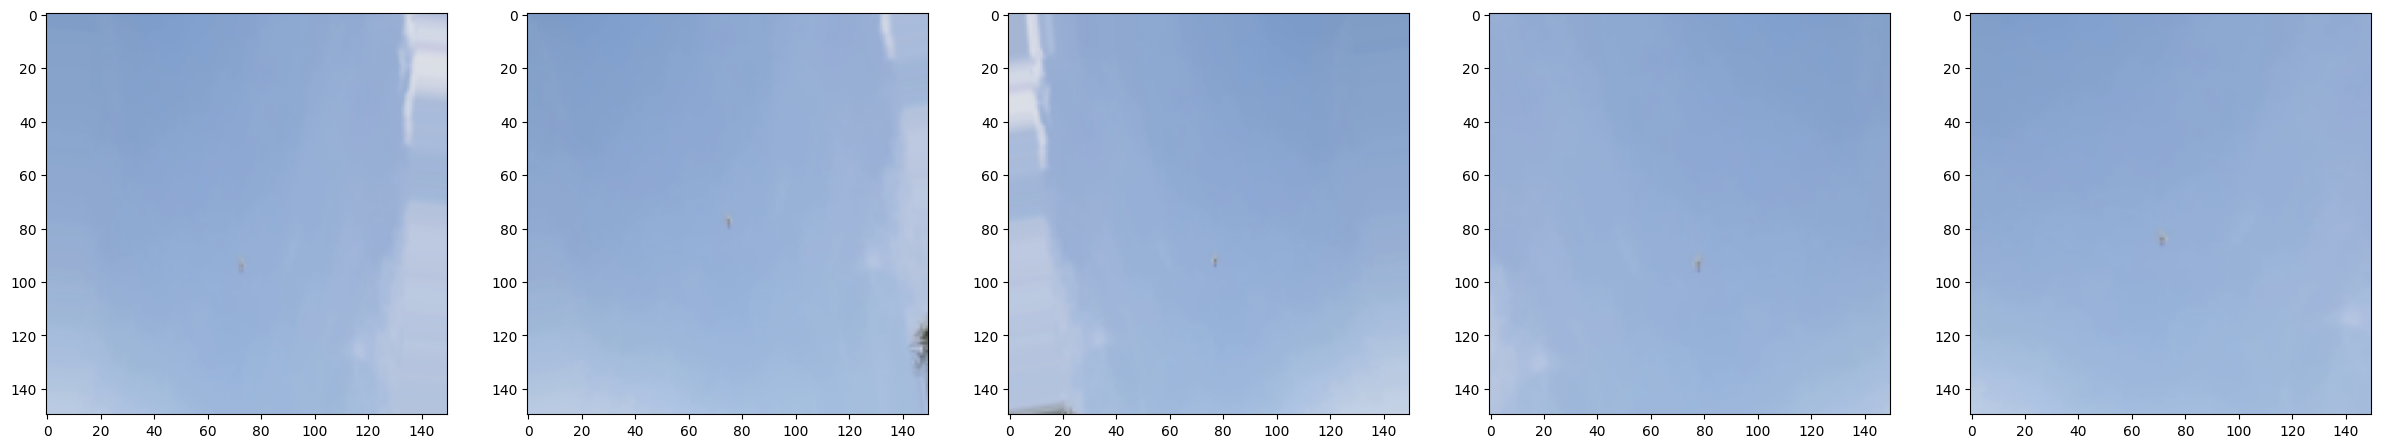

In [18]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (150, 150),
    batch_size = 1, # Images that the models gets in each iteration
    class_mode ='binary') # The last neuron of the network must be binary too

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

Ahora un caso en el que se toman 8 imágenes y se modifican todas una vez cada una

Found 2871 images belonging to 2 classes.
(8, 150, 150, 3)
[1. 1. 1. 0. 1. 0. 1. 1.]


<Figure size 640x480 with 0 Axes>

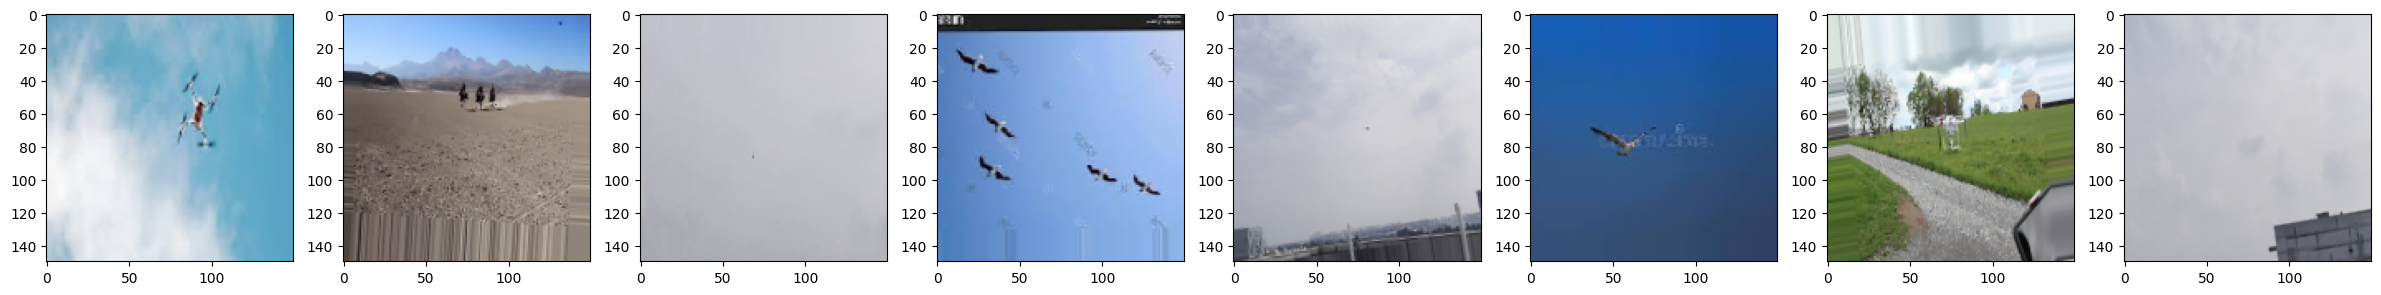

In [19]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (150, 150),
    batch_size = 8,
    class_mode ='binary')

images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

# Red neuronal convolutiva
Se crea la red neuronal convolutiva. Dos capas densas al final donde la última hace la clasificación.

In [20]:
model = models.Sequential()
model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (150,150,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256,activation="relu"))
model.add(layers.Dense(1,activation="sigmoid")) # Binary on the last neuron for 0 or 1

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 219040)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    56,074,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,075,033 (213.91 MB)

 Trainable params: 56,075,033 (213.91 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=["acc"])

Epoch 1/4
359/359 ━━━━━━━━━━━━━━━━━━━━ 77s 205ms/step - acc: 0.6726 - loss: 0.6389
Epoch 2/4
359/359 ━━━━━━━━━━━━━━━━━━━━ 68s 188ms/step - acc: 0.7137 - loss: 0.5731
Epoch 3/4
359/359 ━━━━━━━━━━━━━━━━━━━━ 69s 193ms/step - acc: 0.7360 - loss: 0.5383
Epoch 4/4
359/359 ━━━━━━━━━━━━━━━━━━━━ 65s 180ms/step - acc: 0.7590 - loss: 0.5035


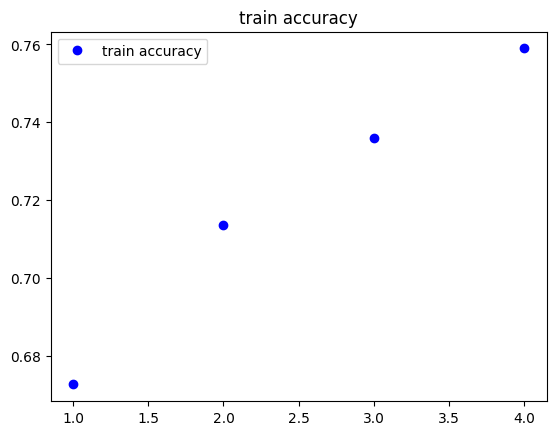

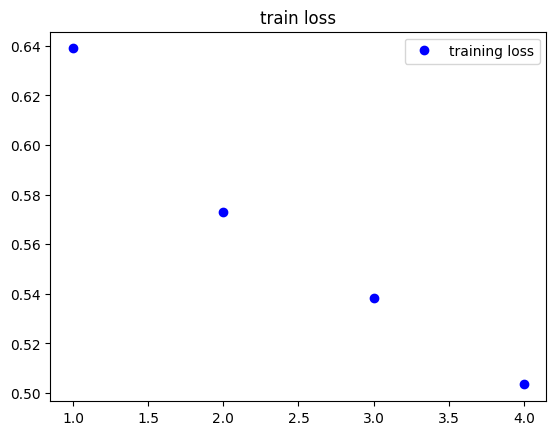

In [22]:
history = model.fit(trainGenerator, epochs = 4)

accuracy = history.history["acc"]
loss = history.history["loss"]

epochs = range(1, len(accuracy)+1)

plt.plot(epochs, accuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, loss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

In [23]:
valDatagen = ImageDataGenerator(1./255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (150, 150),
    batch_size = 20,
    class_mode = "binary")

valLoss, valAccuracy = model.evaluate(valGenerator, steps = 25)
print("\nval accuracy :\n", valAccuracy)

Found 615 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 346ms/step - acc: 0.7640 - loss: 63.5101

val accuracy :
 0.7639999985694885


Con test sólo queremos lo real, por eso aqui siempre sólo se escala

In [24]:
testDatagen = ImageDataGenerator(1./255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (150, 150),
    batch_size = 20,
    class_mode= 'binary')

testLoss, testAccuracy = model.evaluate(testGenerator, steps = 25)
print('\ntest acc :\n', testAccuracy)

Found 618 images belonging to 2 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 343ms/step - acc: 0.7500 - loss: 75.1158

test acc :
 0.75
